In [6]:
!pip install transformers
!pip install timm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 19.2 MB/s  0:00:00


In [14]:
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import requests
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Definir la arquitectura (ViT-S/16)
def create_vit_small(patch_size=16):
    """Versión simplificada - idealmente usa el repo oficial"""
    try:
        # Opción A: Si tienes el repo clonado
        from dinov3.models import vision_transformer as vits
        model = vits.__dict__["vit_small"](patch_size=patch_size)
    except ImportError:
        # Opción B: Usar timm como fallback
        import timm
        model = timm.create_model(
            'vit_small_patch16_224', 
            pretrained=False,
            num_classes=0  # sin cabeza de clasificación
        )
    return model

# 2. Cargar tus pesos locales
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = create_vit_small(patch_size=16)
state_dict = torch.load(
    "/workspace/models/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth", 
    map_location=device,
    weights_only=True
)

# Limpiar state_dict si viene con prefijo 'module.' (DDP)
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

model.load_state_dict(state_dict, strict=False)  # strict=False por si faltan cabezas
model.to(device)
model.eval()

# 3. Preprocesamiento (¡crítico! DINO usa normalize ImageNet)
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 4. Cargar imagen
#url = "http://images.cocodataset.org/val2017/000000039769.jpg"
#img = Image.open(requests.get(url, stream=True).raw).convert("RGB")
img = Image.open("/workspace/assets/vrf/pug.jpg")
img_tensor = transform(img).unsqueeze(0).to(device)  # [1, 3, 224, 224]

# 5. Extraer embeddings
with torch.no_grad():
    features = model.forward_features(img_tensor)  # timm
    # O si es el modelo original de DINOv3:
    # features = model(img_tensor) 
    
    # Generalmente el embedding CLS es el primer token
    if hasattr(features, 'pooler_output'):
        embedding = features.pooler_output
    elif isinstance(features, tuple):
        embedding = features[0][:, 0, :]  # [CLS] token
    else:
        embedding = features[:, 0, :]  # asume [B, tokens, dim]

print(f"Embedding shape: {embedding.shape}")  # Esperado: [1, 384] para ViT-S


Using device: cuda


RuntimeError: Error(s) in loading state_dict for VisionTransformer:
	size mismatch for cls_token: copying a param with shape torch.Size([1, 1, 768]) from checkpoint, the shape in current model is torch.Size([1, 1, 384]).
	size mismatch for patch_embed.proj.weight: copying a param with shape torch.Size([768, 3, 16, 16]) from checkpoint, the shape in current model is torch.Size([384, 3, 16, 16]).
	size mismatch for patch_embed.proj.bias: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([384]).
	size mismatch for blocks.0.norm1.weight: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([384]).
	size mismatch for blocks.0.norm1.bias: copying a param with shape torch.Size([768]) from checkpoint, the shape in current model is torch.Size([384]).
	size mismatch for blocks.0.attn.qkv.weight: copying a param with shape torch.Size([2304, 768]) from checkpoint, the shape in current model is to

Generando mapa de atención...


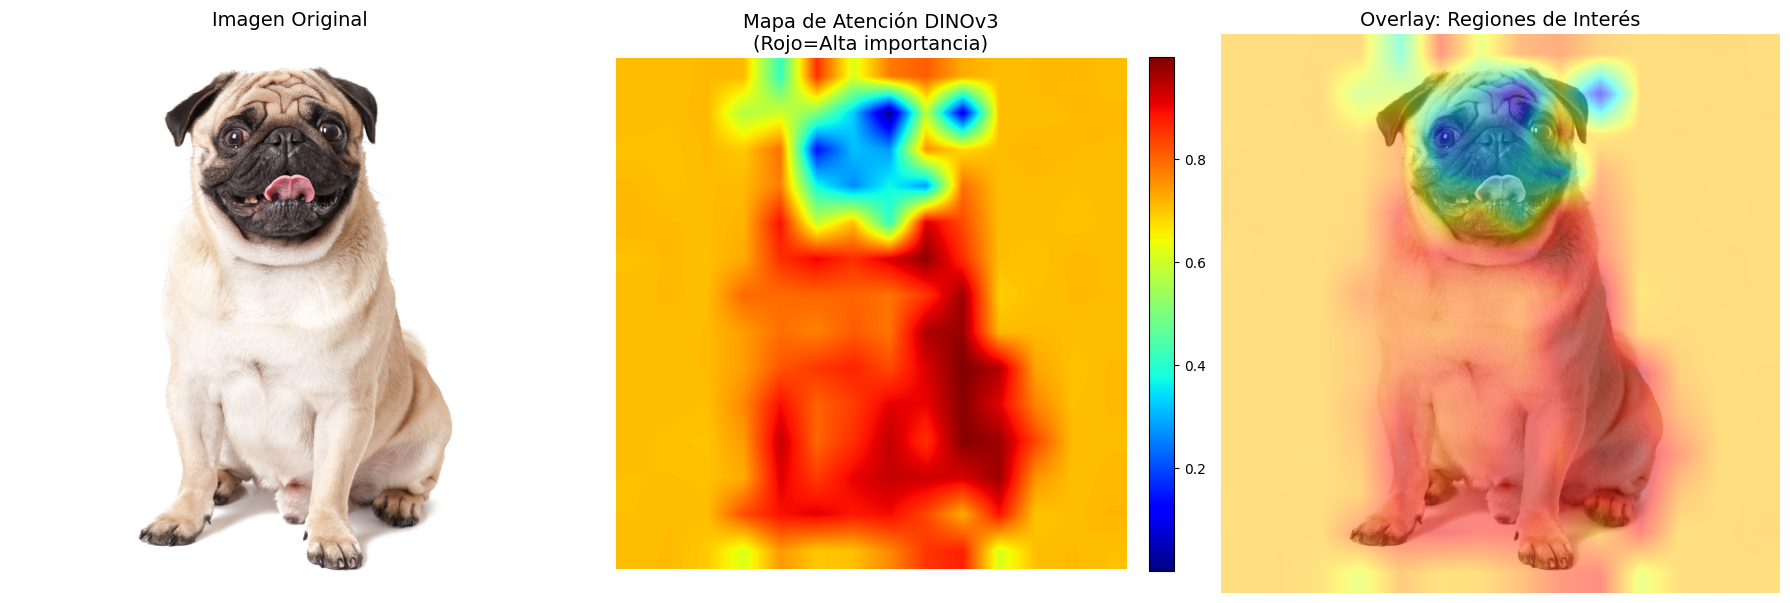

In [12]:
def visualize_dinov3_attention(model, img_tensor, original_img, patch_size=16):
    """
    Visualiza el mapa de atención de DINOv3 usando los tokens de parches.
    Similar a como se visualizan las regiones de interés en perros (cabeza, patas, etc.)
    """
    model.eval()
    device = next(model.parameters()).device
    img_tensor = img_tensor.to(device)
    
    # Extraer features completas (CLS + patch tokens)
    with torch.no_grad():
        # Para timm models
        if hasattr(model, 'forward_features'):
            features = model.forward_features(img_tensor)
        else:
            features = model(img_tensor)
        
        # Obtener todos los tokens
        if isinstance(features, tuple):
            all_tokens = features[0]  # [1, num_tokens, dim]
        else:
            all_tokens = features  # [1, num_tokens, dim]
    
    # Separar CLS token y patch tokens
    cls_token = all_tokens[:, 0:1, :]  # [1, 1, dim]
    patch_tokens = all_tokens[:, 1:, :]  # [1, num_patches, dim]
    
    # Calcular similitud entre CLS y cada patch (atención)
    # Esto muestra qué regiones son más importantes para el embedding global
    cls_normalized = F.normalize(cls_token, p=2, dim=-1)
    patches_normalized = F.normalize(patch_tokens, p=2, dim=-1)
    
    # Similarity map: [1, num_patches]
    attention_scores = torch.matmul(patches_normalized, cls_normalized.transpose(1, 2)).squeeze()
    
    # Reshape a grid 2D (224/16 = 14x14 patches para ViT-S/16)
    num_patches_side = int(np.sqrt(attention_scores.shape[0]))
    attention_map = attention_scores.reshape(num_patches_side, num_patches_side)
    
    # Normalizar a [0, 1]
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())
    attention_map = attention_map.cpu().numpy()
    
    # Redimensionar al tamaño original de la imagen
    attention_resized = cv2.resize(attention_map, (original_img.size[0], original_img.size[1]))
    
    # Crear visualización
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Imagen original
    axes[0].imshow(original_img)
    axes[0].set_title('Imagen Original', fontsize=14)
    axes[0].axis('off')
    
    # Mapa de atención (jet colormap: rojo=alta atención, azul=baja atención)
    im = axes[1].imshow(attention_resized, cmap='jet', interpolation='bilinear')
    axes[1].set_title('Mapa de Atención DINOv3\n(Rojo=Alta importancia)', fontsize=14)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Overlay: imagen + mapa de atención
    axes[2].imshow(original_img)
    axes[2].imshow(attention_resized, cmap='jet', alpha=0.5, interpolation='bilinear')
    axes[2].set_title('Overlay: Regiones de Interés', fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return attention_map

# Visualizar el mapa de atención
print("Generando mapa de atención...")
attention = visualize_dinov3_attention(model, img_tensor, img, patch_size=16)

In [ ]:
def generate_embedding(image_path, model, transform, device):
    """
    Generate embedding from a single image
    
    Args:
        image_path: Path to the image
        model: The pretrained model
        transform: Image preprocessing transforms
        device: CPU or CUDA device
    
    Returns:
        embedding: numpy array of shape (embedding_dim,)
    """
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # Extract embedding
    with torch.no_grad():
        features = model.forward_features(img_tensor)
        
        # Get CLS token (first token)
        if hasattr(features, 'pooler_output'):
            embedding = features.pooler_output
        elif isinstance(features, tuple):
            embedding = features[0][:, 0, :]  # [CLS] token
        else:
            embedding = features[:, 0, :]  # [batch, tokens, dim] -> [batch, dim]
    
    # Convert to numpy
    embedding = embedding.cpu().numpy().squeeze()
    
    return embedding


def print_embedding_statistics(embedding, image_path):
    """Print detailed statistics about the embedding"""
    print("="*70)
    print(f"IMAGE: {image_path}")
    print("="*70)
    print(f"\nEmbedding Shape: {embedding.shape}")
    print(f"Embedding Dimension: {embedding.shape[0]}")
    print(f"Data Type: {embedding.dtype}")
    
    print("\nSTATISTICS:")
    print(f"  Mean:     {embedding.mean():.6f}")
    print(f"  Std Dev:  {embedding.std():.6f}")
    print(f"  Min:      {embedding.min():.6f}")
    print(f"  Max:      {embedding.max():.6f}")
    print(f"  L2 Norm:  {np.linalg.norm(embedding):.6f}")
    
    # Distribution of values
    print("\nVALUE DISTRIBUTION:")
    print(f"  Positive values: {(embedding > 0).sum()} ({(embedding > 0).mean()*100:.1f}%)")
    print(f"  Negative values: {(embedding < 0).sum()} ({(embedding < 0).mean()*100:.1f}%)")
    print(f"  Zero values:     {(embedding == 0).sum()} ({(embedding == 0).mean()*100:.1f}%)")
    
    # Percentiles
    print("\nPERCENTILES:")
    percentiles = [0, 25, 50, 75, 100]
    for p in percentiles:
        val = np.percentile(embedding, p)
        print(f"  {p:3d}%: {val:8.6f}")
    
    print("\nFIRST 20 VALUES:")
    print(f"  {embedding[:20]}")
    
    print("\nLAST 20 VALUES:")
    print(f"  {embedding[-20:]}")
    
    print("="*70)


# Generate embedding for the sample image
image_path = "/workspace/assets/vrf/pug.jpg"
print(f"Generating embedding for: {image_path}\n")

embedding = generate_embedding(image_path, model, transform, device)

# Print statistics
print_embedding_statistics(embedding, image_path)


## Generate Embeddings from Image

Extract embeddings and display statistics